Split Test

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_excel('/content/Project_KDKA/processed.cleveland 1.xlsx')
df.replace('?', np.nan, inplace=True)

df = df.apply(pd.to_numeric, errors='coerce')

df.dropna(inplace=True)

print(f"Total baris setelah remove missing: {len(df)}")

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x > 0 else 0)

print("\n             DATA SPLIT")
print("----------------------------------------")
print(f" Nilai unik target sebelum : {df.iloc[:, -1].unique()}")
print(f" Nilai unik target sesudah : {y.unique()}")
print("----------------------------------------")
print(f"         Distribusi Target")
print("----------------------------------------")
print(f" Sehat (0)           : {(y==0).sum()} pasien")
print(f" Penyakit jantung (1): {(y==1).sum()} pasien")
print(" ---------------------------------------")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nJumlah data train : {X_train.shape[0]}")
print(f"Jumlah data test  : {X_test.shape[0]}")

print("\nDISTRIBUSI TARGET TRAIN ")
print(y_train.value_counts())

print("\nDISTRIBUSI TARGET TEST ")
print(y_test.value_counts())

Total baris setelah remove missing: 297

             DATA SPLIT
----------------------------------------
 Nilai unik target sebelum : [0 2 1 3 4]
 Nilai unik target sesudah : [0 1]
----------------------------------------
         Distribusi Target
----------------------------------------
 Sehat (0)           : 160 pasien
 Penyakit jantung (1): 137 pasien
 ---------------------------------------

Jumlah data train : 237
Jumlah data test  : 60

DISTRIBUSI TARGET TRAIN 
 target
0    128
1    109
Name: count, dtype: int64

DISTRIBUSI TARGET TEST 
 target
0    32
1    28
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel('/content/Project_KDKA/processed.cleveland 1.xlsx')
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

cols_to_check = [' slope', ' ca', 'cp', ' restecg', ' thal']

for col in cols_to_check:
    print(f"\n{'='*40}")
    print(f"Kolom: {col}")
    print(f"Nilai unik: {sorted(df[col].unique())}")

    counts = df[col].value_counts().sort_index()
    total = len(df)

    print(f"\n{'Nilai':<10} {'Jumlah':<10} {'Persentase'}")
    print(f"{'-'*30}")
    for val, count in counts.items():
        pct = (count / total) * 100
        print(f"{val:<10} {count:<10} {pct:.1f}%")


Kolom:  slope
Nilai unik: [np.int64(1), np.int64(2), np.int64(3)]

Nilai      Jumlah     Persentase
------------------------------
1          139        46.8%
2          137        46.1%
3          21         7.1%

Kolom:  ca
Nilai unik: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Nilai      Jumlah     Persentase
------------------------------
0          174        58.6%
1          65         21.9%
2          38         12.8%
3          20         6.7%

Kolom: cp
Nilai unik: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Nilai      Jumlah     Persentase
------------------------------
1          23         7.7%
2          49         16.5%
3          83         27.9%
4          142        47.8%

Kolom:  restecg
Nilai unik: [np.int64(0), np.int64(1), np.int64(2)]

Nilai      Jumlah     Persentase
------------------------------
0          147        49.5%
1          4          1.3%
2          146        49.2%

Kolom:  thal
Nilai unik: [np.int64(3), np.int64(6), np.int64(7

Outlier

In [ ]:
import joblib
#IQR + CLIPPING TRAIN ONLY
iqr_bounds = {}
num_cols = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak']

for col in num_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_bounds[col] = (lower, upper)

    before_train = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    before_test = ((X_test[col] < lower) | (X_test[col] > upper)).sum()

    # clipping
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

    after_train = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    after_test = ((X_test[col] < lower) | (X_test[col] > upper)).sum()

    print(f"""
    Feature             : {col}
    Q1                  : {Q1:.2f}
    Q3                  : {Q3:.2f}
    IQR                 : {IQR:.2f}
    Lower               : {lower:.2f}
    Upper               : {upper:.2f}

    TRAIN Outlier Before: {before_train}
    TRAIN Outlier After : {after_train}

    TEST Outlier Before : {before_test}
    TEST Outlier After  : {after_test}
    """)

    joblib.dump(iqr_bounds, 'iqr_bounds.pkl')


    Feature             : age
    Q1                  : 48.00
    Q3                  : 62.00
    IQR                 : 14.00
    Lower               : 27.00
    Upper               : 83.00

    TRAIN Outlier Before: 0
    TRAIN Outlier After : 0

    TEST Outlier Before : 0
    TEST Outlier After  : 0
    

    Feature             : chol
    Q1                  : 212.00
    Q3                  : 277.00
    IQR                 : 65.00
    Lower               : 114.50
    Upper               : 374.50

    TRAIN Outlier Before: 0
    TRAIN Outlier After : 0

    TEST Outlier Before : 0
    TEST Outlier After  : 0
    

    Feature             : trestbps
    Q1                  : 120.00
    Q3                  : 140.00
    IQR                 : 20.00
    Lower               : 90.00
    Upper               : 170.00

    TRAIN Outlier Before: 0
    TRAIN Outlier After : 0

    TEST Outlier Before : 0
    TEST Outlier After  : 0
    

    Feature             : thalach
    Q1                

Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

X_train.columns = X_train.columns.str.strip()
X_test.columns  = X_test.columns.str.strip()

X_train = pd.get_dummies(X_train,columns=['cp', ' restecg',' slope',' thal'], drop_first=False)
X_test  = pd.get_dummies(X_test,columns=['cp', ' restecg',' slope',' thal'], drop_first=False)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

# le = LabelEncoder()
# X_train[] = le.fit_transform(X_train[].astype(int))
# X_test[]  = le.transform(X_test[].astype(int))

# Convert True/False ke 1/0
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

print(f"[5] Shape X_train setelah encoding : {X_train.shape}")
print(f"    Shape X_test  setelah encoding : {X_test.shape}")

print("\n Kolom X_train:")
for col in X_train.columns:
    print(f"  - {col}")

print("\n Sample X_train (5 baris pertama):")
print(X_train.head())

print("\n Nilai unik per kolom:")
for col in X_train.columns:
    print(f"  {col}: {sorted(X_train[col].unique())}")

KeyError: "None of [Index(['cp', ' restecg', ' slope', ' thal'], dtype='object')] are in the [columns]"

In [ ]:
print(df.columns.tolist())


['age', ' sex', 'cp', 'trestbps', 'chol', ' fbs', ' restecg', 'thalach', ' exang', 'oldpeak', ' slope', ' ca', ' thal', ' target']


SCALLING

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# # 1. LOAD & REMOVE MISSING VALUE
# df = pd.read_excel('/content/Project_KDKA/processed.cleveland 1.xlsx')
# df.replace('?', np.nan, inplace=True)
# df = df.apply(pd.to_numeric, errors='coerce')
# df.dropna(inplace=True)
# print(f"[1] Total baris setelah remove missing: {len(df)}")

# # 2. ENCODING TARGET
# X = df.iloc[:, :-1]
# y = df.iloc[:, -1].apply(lambda x: 1 if x > 0 else 0)

# print(f"\n[2] Encoding target:")
# print(f"    Nilai unik sebelum : {sorted(df.iloc[:, -1].unique())}")
# print(f"    Nilai unik sesudah : {sorted(y.unique())}")
# print(f"    Sehat (0)           : {(y==0).sum()} pasien")
# print(f"    Penyakit jantung (1): {(y==1).sum()} pasien")

# # 3. TRAIN-TEST SPLIT
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )
# print(f"\n[3] Train-test split:")
# print(f"    Data train : {len(X_train)} baris")
# print(f"    Data test  : {len(X_test)} baris")


# X_train.columns = X_train.columns.str.strip()
# X_test.columns  = X_test.columns.str.strip()

# # 4. OUTLIER HANDLING IQR (clipping dari train)
# num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# print(f"\n[4] Outlier handling (IQR clipping):")
# for col in num_cols:
#     Q1 = X_train[col].quantile(0.25)
#     Q3 = X_train[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
#     before = ((X_train[col] < lower) | (X_train[col] > upper)).sum()

#     X_train[col] = X_train[col].clip(lower, upper)
#     X_test[col]  = X_test[col].clip(lower, upper)

#     after = ((X_train[col] < lower) | (X_train[col] > upper)).sum()

#     print(f"""
#     Fitur                 : {col}
#     Q1                    : {Q1:.2f}
#     Q3                    : {Q3:.2f}
#     IQR                   : {IQR:.2f}
#     Lower                 : {lower:.2f}
#     Upper                 : {upper:.2f}
#     Outlier sebelum clip  : {before}
#     Outlier sesudah clip  : {after}
#     """)

# print(f"    Data train : {len(X_train)} baris")
# print(f"    Data test  : {len(X_test)} baris")

# X_train = pd.get_dummies(X_train, columns=['cp', 'restecg'], drop_first=False)
# X_test  = pd.get_dummies(X_test,  columns=['cp', 'restecg'], drop_first=False)
# X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

# le = LabelEncoder()
# X_train['thal'] = le.fit_transform(X_train['thal'].astype(int))
# X_test['thal']  = le.transform(X_test['thal'].astype(int))

# bool_cols = [col for col in X_train.columns if X_train[col].dtype == bool]
# if bool_cols:
#     X_train[bool_cols] = X_train[bool_cols].astype(int)
#     X_test[bool_cols]  = X_test[bool_cols].astype(int)

# print(f"\n[5] Encoding selesai:")
# print(f"    Shape X_train : {X_train.shape}")
# print(f"    Shape X_test  : {X_test.shape}")
# print(f"\n    Kolom X_train:")
# for col in X_train.columns:
#     print(f"      - {col}")

# print("\n    Sample X_train (5 baris pertama):")
# print(X_train.head())
# print("\n    Nilai unik per kolom:")

for col in X_train.columns:
    print(f"      {col}: {sorted(X_train[col].unique())}")

# 6. SCALING
X_train_stats = X_train.copy()  # simpan sebelum scaling

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("\n[6] Scaling selesai (StandardScaler)")
print(f"    Shape X_train scaled : {X_train_scaled.shape}")
print(f"    Shape X_test  scaled : {X_test_scaled.shape}")

print("\n    Sample X_train setelah scaling (5 baris pertama):")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(X_train_scaled.head().round(4))

print("\n" + "="*135)
print(f"{'Fitur':<15} {'Min Sblm':>10} {'Max Sblm':>10} {'Mean Sblm':>10} {'Std Sblm':>10} {'Min Ssdh':>10} {'Max Ssdh':>10} {'Mean Ssdh':>10} {'Std Ssdh':>10}")
print("="*135)
for col in X_train.columns:
    print(f"{col:<15} {X_train_stats[col].min():>10.4f} {X_train_stats[col].max():>10.4f} {X_train_stats[col].mean():>10.4f} {X_train_stats[col].std():>10.4f} {X_train_scaled[col].min():>10.4f} {X_train_scaled[col].max():>10.4f} {X_train_scaled[col].mean():>10.4f} {X_train_scaled[col].std():>10.4f}")
print("="*135)

      age: [np.int64(34), np.int64(35), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(74), np.int64(76), np.int64(77)]
      sex: [np.int64(0), np.int64(1)]
      trestbps: [np.int64(94), np.int64(100), np.int64(101), np.int64(102), np.int64(104), np.int64(105), np.int64(106), np.int64(108), np.int64(110), np.int64(112), np.int64(114), np.int64(115), np.int64(117), np.int64(118), np.int64(120), np.int64(122), np.int64(123), np.int64(124), np.int64(125), np.int64(126), np.int64(128), np.int64(130), np.int64(132), np.int64(134), np.int64(135),

Eksperimen Hyperparameter Tuning (Pencarian Nilai K Terbaik)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Gabung train+test untuk CV
X_full = pd.concat([X_train_scaled, X_test_scaled]).reset_index(drop=True)
y_full = pd.concat([y_train, y_test]).reset_index(drop=True)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics = ['euclidean', 'manhattan', 'minkowski']

print("="*70)
print("WEIGHTED KNN — 10-Fold Cross Validation")
print("="*70)
best_score = 0
best_k = 0
best_metric = ""

for metric in metrics:
    print(f"\n=== Metrik Jarak: {metric.upper()} ===")
    print(f"{'K':<5} {'CV Accuracy':>12} {'Std':>8} {'Min':>8} {'Max':>8}")
    print("-"*45)
    for k in range(1, 16, 2):
        knn = KNeighborsClassifier(
            n_neighbors=k,
            weights='distance',
            metric=metric
        )
        scores = cross_val_score(knn, X_full, y_full, cv=skf, scoring='accuracy')

        mean_acc = scores.mean()
        print(f"{k:<5} {mean_acc:>12.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}")

        if mean_acc > best_score:
            best_score = mean_acc
            best_k = k
            best_metric = metric
print("\n" + "="*70)
print("REKOMENDASI PARAMETER TERBAIK")
print("="*70)
print(f"Metrik Jarak Terbaik : {best_metric.upper()}")
print(f"Nilai K Optimal      : {best_k}")
print(f"Akurasi (CV Mean)    : {best_score:.4f}")
print("="*70)


WEIGHTED KNN — 10-Fold Cross Validation

=== Metrik Jarak: EUCLIDEAN ===
K      CV Accuracy      Std      Min      Max
---------------------------------------------
1           0.7506   0.0421   0.6552   0.8000
3           0.7841   0.0540   0.6897   0.9000
5           0.7878   0.0340   0.7333   0.8333
7           0.8010   0.0581   0.7241   0.9000
9           0.8147   0.0625   0.7000   0.9333
11          0.8179   0.0629   0.7333   0.9333
13          0.8213   0.0511   0.7586   0.9000
15          0.8247   0.0547   0.7586   0.9000

=== Metrik Jarak: MANHATTAN ===
K      CV Accuracy      Std      Min      Max
---------------------------------------------
1           0.7841   0.0398   0.6897   0.8333
3           0.8109   0.0545   0.7241   0.9000
5           0.7907   0.0689   0.6552   0.9000
7           0.8010   0.0518   0.7000   0.9000
9           0.8113   0.0569   0.7000   0.9000
11          0.8111   0.0647   0.7000   0.9333
13          0.8078   0.0570   0.7000   0.9000
15          0.8078  

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

X_full = pd.concat([X_train_scaled, X_test_scaled]).reset_index(drop=True)
y_full = pd.concat([y_train, y_test]).reset_index(drop=True)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics = ['euclidean', 'manhattan', 'chebyshev']

print("="*100)
print("WEIGHTED KNN — 10-Fold Cross Validation")
print("="*100)

best_acc = 0
best_rec = 0
best_k = 0
best_metric = ""

for metric in metrics:
    print(f"\n=== Metrik Jarak: {metric.upper()} ===")
    print(f"{'K':<5} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Std':>8} {'Min':>8} {'Max':>8}")
    print("-"*75)
    for k in range(1, 16, 2):
        knn = KNeighborsClassifier(
            n_neighbors=k,
            weights='distance',
            metric=metric
        )
        acc  = cross_val_score(knn, X_full, y_full, cv=skf, scoring='accuracy')
        prec = cross_val_score(knn, X_full, y_full, cv=skf, scoring='precision')
        rec  = cross_val_score(knn, X_full, y_full, cv=skf, scoring='recall')
        f1   = cross_val_score(knn, X_full, y_full, cv=skf, scoring='f1')

        print(f"{k:<5} {acc.mean():>10.4f} {prec.mean():>10.4f} {rec.mean():>10.4f} {f1.mean():>10.4f} {acc.std():>8.4f} {acc.min():>8.4f} {acc.max():>8.4f}")

        # Pilih terbaik berdasarkan Recall, K <= 7
        if k <= 7 and rec.mean() > best_rec:
            best_rec = rec.mean()
            best_acc = acc.mean()
            best_k = k
            best_metric = metric

print("\n" + "="*100)
print("REKOMENDASI PARAMETER TERBAIK (Prioritas Recall, K ≤ 7)")
print("="*100)
print(f"Metrik Jarak Terbaik : {best_metric.upper()}")
print(f"Nilai K Optimal      : {best_k}")
print(f"Akurasi (CV Mean)    : {best_acc:.4f}")
print(f"Recall (CV Mean)     : {best_rec:.4f}")
print("="*100)

WEIGHTED KNN — 10-Fold Cross Validation

=== Metrik Jarak: EUCLIDEAN ===
K       Accuracy  Precision     Recall         F1      Std      Min      Max
---------------------------------------------------------------------------
1         0.7506     0.7430     0.7220     0.7247   0.0421   0.6552   0.8000
3         0.7841     0.7910     0.7505     0.7610   0.0540   0.6897   0.9000
5         0.7878     0.8101     0.7231     0.7551   0.0340   0.7333   0.8333
7         0.8010     0.8278     0.7297     0.7693   0.0581   0.7241   0.9000
9         0.8147     0.8502     0.7368     0.7837   0.0625   0.7000   0.9333
11        0.8179     0.8521     0.7363     0.7854   0.0629   0.7333   0.9333
13        0.8213     0.8539     0.7505     0.7911   0.0511   0.7586   0.9000
15        0.8247     0.8582     0.7511     0.7947   0.0547   0.7586   0.9000

=== Metrik Jarak: MANHATTAN ===
K       Accuracy  Precision     Recall         F1      Std      Min      Max
------------------------------------------------

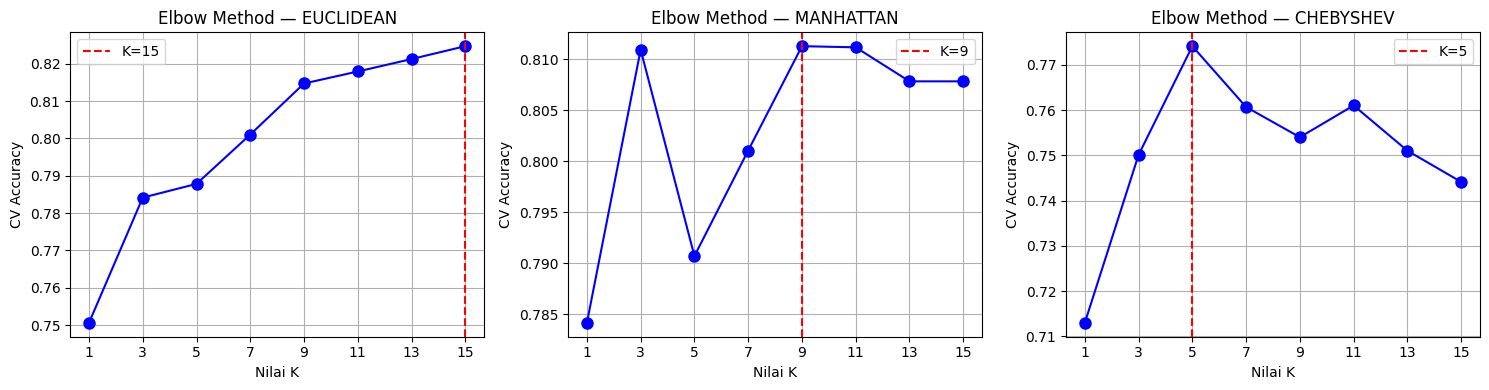

Grafik tersimpan!


In [ ]:
import matplotlib.pyplot as plt

metrics = ['euclidean', 'manhattan', 'chebyshev']
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
k_range = range(1, 16, 2)

plt.figure(figsize=(15, 4))

for i, metric in enumerate(metrics):
    accuracies = []
    for k in k_range:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            weights='distance',
            metric=metric
        )
        scores = cross_val_score(knn, X_full, y_full, cv=skf, scoring='accuracy')
        accuracies.append(scores.mean())

    plt.subplot(1, 3, i+1)
    plt.plot(list(k_range), accuracies, 'bo-', markersize=8)
    plt.xlabel('Nilai K')
    plt.ylabel('CV Accuracy')
    plt.title(f'Elbow Method — {metric.upper()}')
    plt.xticks(list(k_range))
    plt.grid(True)

    best_k = list(k_range)[accuracies.index(max(accuracies))]
    plt.axvline(x=best_k, color='red', linestyle='--', label=f'K={best_k}')
    plt.legend()

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan!")

MODEL FINAL — Manhattan K=3 (Prioritas Recall)

Classification Report:
                  precision    recall  f1-score   support

           Sehat       0.78      0.88      0.82        32
Penyakit Jantung       0.83      0.71      0.77        28

        accuracy                           0.80        60
       macro avg       0.81      0.79      0.80        60
    weighted avg       0.80      0.80      0.80        60

Confusion Matrix:
[[28  4]
 [ 8 20]]


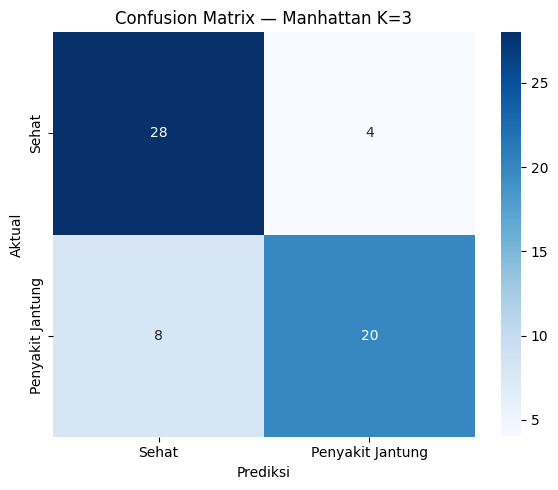

Grafik tersimpan!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── MODEL FINAL ───────────────────────────────────────────────
print("="*100)
print("MODEL FINAL — Manhattan K=3 (Prioritas Recall)")
print("="*100)

model_final = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='manhattan'
)
model_final.fit(X_train_scaled, y_train)
y_pred = model_final.predict(X_test_scaled)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Sehat', 'Penyakit Jantung']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sehat', 'Penyakit Jantung'],
            yticklabels=['Sehat', 'Penyakit Jantung'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix — Manhattan K=3')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Grafik tersimpan!")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Gabungkan data untuk proses Cross Validation
X_full = pd.concat([X_train_scaled, X_test_scaled]).reset_index(drop=True)
y_full = pd.concat([y_train, y_test]).reset_index(drop=True)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics = ['euclidean', 'manhattan', 'chebyshev']

print("="*100)
print("WEIGHTED KNN — 10-Fold Cross Validation")
print("="*100)

best_acc = 0
best_rec = 0
best_k = 0
best_metric = ""

# Loop Eksperimen Parameter
for metric in metrics:
    print(f"\n=== Metrik Jarak: {metric.upper()} ===")
    print(f"{'K':<5} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Std':>8} {'Min':>8} {'Max':>8}")
    print("-"*75)
    for k in range(1, 16, 2):
        knn = KNeighborsClassifier(
            n_neighbors=k,
            weights='distance',
            metric=metric
        )
        acc  = cross_val_score(knn, X_full, y_full, cv=skf, scoring='accuracy')
        prec = cross_val_score(knn, X_full, y_full, cv=skf, scoring='precision')
        rec  = cross_val_score(knn, X_full, y_full, cv=skf, scoring='recall')
        f1   = cross_val_score(knn, X_full, y_full, cv=skf, scoring='f1')

        print(f"{k:<5} {acc.mean():>10.4f} {prec.mean():>10.4f} {rec.mean():>10.4f} {f1.mean():>10.4f} {acc.std():>8.4f} {acc.min():>8.4f} {acc.max():>8.4f}")

        # Pilih terbaik berdasarkan Recall, K <= 7
        if k <= 7 and rec.mean() > best_rec:
            best_rec = rec.mean()
            best_acc = acc.mean()
            best_k = k
            best_metric = metric

print("\n" + "="*100)
print("REKOMENDASI PARAMETER TERBAIK (Prioritas Recall, K ≤ 7)")
print("="*100)
print(f"Metrik Jarak Terbaik : {best_metric.upper()}")
print(f"Nilai K Optimal      : {best_k}")
print(f"Akurasi (CV Mean)    : {best_acc:.4f}")
print(f"Recall (CV Mean)     : {best_rec:.4f}")
print("="*100)

# ==========================================
# 1. MEMBUAT DAN MELATIH MODEL FINAL
# ==========================================
print("\n" + ">"*40 + " PROSES FINALISASI MODEL " + "<"*40)
print(f"Melatih kembali model menggunakan {best_metric.upper()} dengan K={best_k} pada seluruh dataset...")

model_final = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    metric=best_metric
)

# Fit ke seluruh data menggunakan DataFrame agar menyimpan informasi nama kolom
model_final.fit(X_full, y_full)
print("✔ Model Final Berhasil Dilatih dan Siap Digunakan!")
print("="*100)

# ==========================================
# 2. SIMULASI DETEKSI PASIEN BARU (DEPLOYMENT INTERAKTIF)
# ==========================================
print("\n" + "="*100)
print("SISTEM PREDIKSI OTOMATIS: PASIEN BARU")
print("="*100)

# Mengambil baris pertama sebagai DataFrame agar format nama kolom tetap terjaga (Mencegah UserWarning)
contoh_pasien_baru = X_full.iloc[[0]]

# Prediksi Label (Sakit/Sehat)
prediksi_label = model_final.predict(contoh_pasien_baru)

# Hitung Persentase Keyakinan AI (Confidence Score)
prediksi_probabilitas = model_final.predict_proba(contoh_pasien_baru)
confidence_score = np.max(prediksi_probabilitas) * 100

# Output Diagnosa
status_diagnosa = "TERINDIKASI SAKIT JANTUNG (1)" if prediksi_label[0] == 1 else "KONDISI SEHAT/NORMAL (0)"

print(f"Hasil Analisis AI : {status_diagnosa}")
print(f"Keyakinan Sistem  : {confidence_score:.2f}%")
print("-"*100)
print("Catatan: Hasil evaluasi performa model didasarkan pada metrik acuan dan tingkat sensitivitas (Recall).")
print("="*100)

WEIGHTED KNN — 10-Fold Cross Validation

=== Metrik Jarak: EUCLIDEAN ===
K       Accuracy  Precision     Recall         F1      Std      Min      Max
---------------------------------------------------------------------------
1         0.7506     0.7430     0.7220     0.7247   0.0421   0.6552   0.8000
3         0.7841     0.7910     0.7505     0.7610   0.0540   0.6897   0.9000
5         0.7878     0.8101     0.7231     0.7551   0.0340   0.7333   0.8333
7         0.8010     0.8278     0.7297     0.7693   0.0581   0.7241   0.9000
9         0.8147     0.8502     0.7368     0.7837   0.0625   0.7000   0.9333
11        0.8179     0.8521     0.7363     0.7854   0.0629   0.7333   0.9333
13        0.8213     0.8539     0.7505     0.7911   0.0511   0.7586   0.9000
15        0.8247     0.8582     0.7511     0.7947   0.0547   0.7586   0.9000

=== Metrik Jarak: MANHATTAN ===
K       Accuracy  Precision     Recall         F1      Std      Min      Max
------------------------------------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')